In [1]:
%run ../../../setup_workspace.py # ../ means level up 
from scipy.interpolate import interp1d

# **Functions**

In [2]:
def linear(x, k, b):
    return k * x + b
    
def linear_2points(x, x1, y1, x2, y2):
    k = (y2 - y1) / (x2 - x1)
    b = y1 - k * x1

    return linear(x, k, b)

def linear_2(x, y, i1, i2):
    x1 = x[i1]
    y1 = y[i1]
    x2 = x[i2]
    y2 = y[i2]
    return linear_2points(x, x1, y1, x2, y2)

def gaussian(x, A, x0, sigma):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))

def voigt(x, A, x0, sigma, gamma):
    return A * voigt_profile(x - x0, sigma, gamma) / voigt_profile(0, sigma, gamma)

def shifted_interp(x, shift, ampl):
    f = interpolate.interp1d(q_amorph + shift, I_amorph, kind='cubic')
    return ampl * f(x + shift)

def const(x, C):
    return np.ones(len(x)) * C

# **Analysis**

In [3]:
def scatter(x,y, index):
    for i in index:
        plt.scatter(x[i], y[i], marker='x', color='black', zorder=10)

def plot(x, y):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name='SAXS'))
    fig.show()

from scipy.interpolate import CubicSpline
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import PchipInterpolator

def cryst(X, Y, background, alpha):
    Cr = np.trapezoid((Y - background) * X ** 2, X) 
    All = np.trapezoid(Y * X ** 2, X)
    Amorph = Cr - All
    return Cr / All


632.2056


C:\Users\LabPCA\AppData\Local\Temp\ipykernel_2812\282691966.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_table(path, skiprows=30, names=['q', 'I', ''], sep='    ')


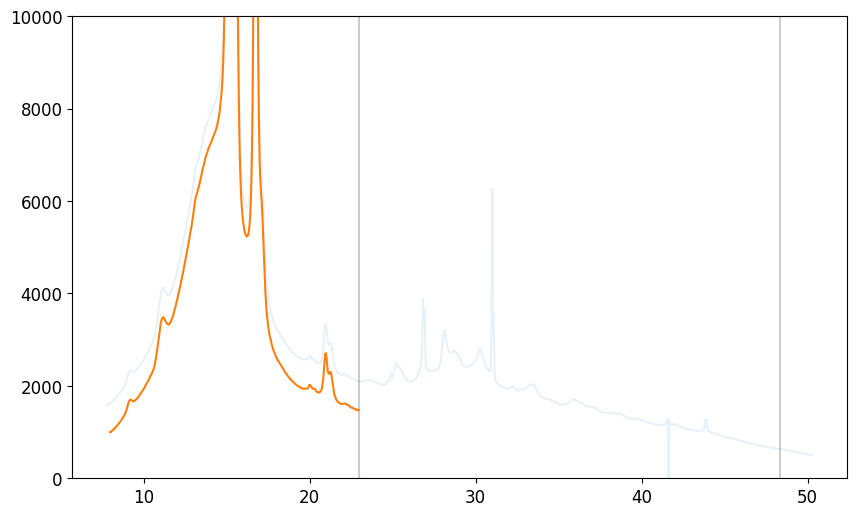

In [152]:
path = r"E:\PEG_PCL\Alina_data\Additional\Degradation_PCL_M4_14daysRT_WAXS_0000.dat"
# Exp = BM26_experiment(path)
df = pd.read_table(path, skiprows=30, names=['q', 'I', ''], sep='    ')
# df = pd.read_table(path, skiprows=1, names=['q', 'I', 'err'], sep=' ')
q, I = np.array(df['q']), np.array(df['I'])
l, r = 7.97, 23
mask = (q > l) * (q < r)

X = q[mask]
Y = I[mask]


alpha = 0.2

plt.plot(q, I, alpha=0.1)
plt.ylim(0, 1e4)

plt.axvline(x=X[-1], color='black', alpha=0.2)

# point = 3400
point = 1900
plt.axvline(x=q[point], color='black', alpha=0.2)
print(I[point])

Y -= I[point]

plt.plot(X, Y)


0.25255597453379214
E:\PEG_PCL\Alina_data\Additional\Degradation_PCL_M4_14daysRT_WAXS_0000.dat
0.25255597453379214


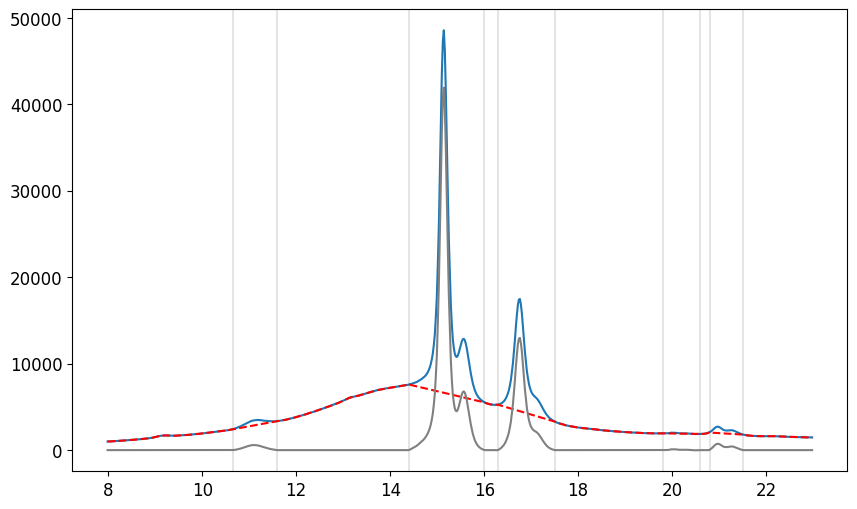

In [153]:
plt.plot(X, Y)

l1, r1 = 10.66, 11.6
l2, r2 = 14.4, 16.0
l3, r3 = 16.3, 17.5
l4, r4 = 19.8, 20.6
l5, r5 = 20.8, 21.5


mask_peaks = np.ones_like(X, dtype=bool)
for l, r in [(l1, r1), (l2, r2), (l3, r3), 
             (l4, r4), (l5, r5),
            ]:
    plt.axvline(x=l, color='black', alpha=0.1)
    plt.axvline(x=r, color='black', alpha=0.1)
    mask_peaks &= ~((X >= l) & (X <= r))

background = np.interp(X, X[mask_peaks], Y[mask_peaks])
Peaks = Y-background
plt.plot(X, background, 'r--', label='Background')
plt.plot(X, Peaks, 'grey', label='Background')

Cr = np.trapezoid(Peaks * X ** 2, X) 
All = np.trapezoid(Y * X ** 2, X) 

index =  Cr / All
print( Cr / All)
print(path)
print( index / (1 - 0))

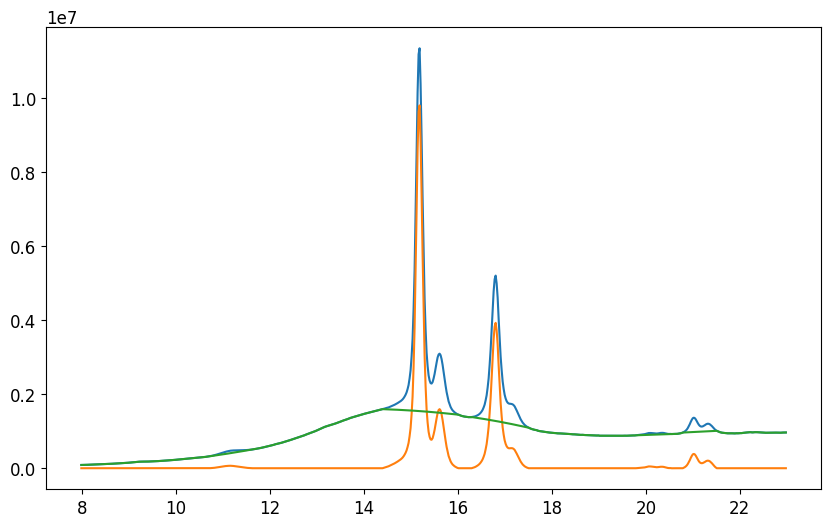

In [145]:
plt.plot(X, Y * X ** 2)
plt.plot(X, Peaks * X ** 2)
plt.plot(X, background * X ** 2)